In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

# Фиксация seed
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
])

# Загрузка CIFAR10
train_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Разбиение train/val (80/20)
train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size
train_dataset, val_dataset = random_split(train_full, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Sanity-check
x, y = next(iter(train_loader))
print(f'Batch X shape: {x.shape}, Batch Y shape: {y.shape}')
print(f'X min: {x.min():.4f}, X max: {x.max():.4f}')

100%|██████████| 170M/170M [04:33<00:00, 624kB/s]    


Batch X shape: torch.Size([64, 3, 32, 32]), Batch Y shape: torch.Size([64])
X min: -1.0000, X max: 1.0000


In [3]:
class MLP(nn.Module):
    def __init__(self, use_dropout=False, use_batchnorm=False, p_dropout=0.3):
        super().__init__()
        self.flatten = nn.Flatten()
        
        layers = []
        # Входной размер для CIFAR10 (32x32 пикселя * 3 канала)
        layers.append(nn.Linear(32 * 32 * 3, 256))
        if use_batchnorm: layers.append(nn.BatchNorm1d(256))
        layers.append(nn.ReLU())
        if use_dropout: layers.append(nn.Dropout(p_dropout))
        
        # Слой 2
        layers.append(nn.Linear(256, 128))
        if use_batchnorm: layers.append(nn.BatchNorm1d(128))
        layers.append(nn.ReLU())
        if use_dropout: layers.append(nn.Dropout(p_dropout))
        
        # Выходной слой
        layers.append(nn.Linear(128, 10))
        
        self.network = nn.Sequential(*layers)
        
        # Сохраняем конфиг для отчета
        self.config_summary = f"Hidden: 256-128, BN: {use_batchnorm}, DO: {use_dropout}"

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return running_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)
            running_loss += loss.item() * X.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return running_loss / total, correct / total
def run_experiment(exp_id, model, optimizer, criterion, epochs, patience=None):
    set_seed(SEED)
    model = model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    best_val_loss = float('inf')
    best_val_acc = 0.0
    best_state = None
    epochs_no_improve = 0
    actual_epochs = 0
    
    for epoch in range(epochs):
        actual_epochs += 1
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc = evaluate(model, val_loader, criterion)
        
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_val_acc = v_acc
            best_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            
        if patience and epochs_no_improve >= patience:
            print(f"[{exp_id}] Early stopping at epoch {epoch+1}")
            break
            
    # Возвращаем лучшие метрики и историю
    return best_val_acc, best_val_loss, history, best_state, actual_epochs

In [4]:
results = []
histories = {}
best_models_states = {}

epochs_A = 15
epochs_B = 8

# E1, E2, E3
experiments_A = [
    ('E1', MLP(use_dropout=False, use_batchnorm=False), optim.Adam),
    ('E2', MLP(use_dropout=True, use_batchnorm=False), optim.Adam),
    ('E3', MLP(use_dropout=False, use_batchnorm=True), optim.Adam)
]

for exp_id, model, Opt in experiments_A:
    opt = Opt(model.parameters(), lr=1e-3)
    val_acc, val_loss, hist, state, ep = run_experiment(exp_id, model, opt, nn.CrossEntropyLoss(), epochs_A)
    histories[exp_id] = hist
    best_models_states[exp_id] = state
    results.append({
        'experiment_id': exp_id, 'dataset': 'CIFAR10', 'seed': SEED, 
        'model_summary': model.config_summary, 'optimizer': 'Adam', 
        'lr': 1e-3, 'momentum': 0, 'weight_decay': 0, 'epochs_trained': ep, 
        'best_val_accuracy': val_acc, 'best_val_loss': val_loss
    })

# E4
best_reg_exp = 'E3' if results[2]['best_val_accuracy'] > results[1]['best_val_accuracy'] else 'E2'
use_bn = (best_reg_exp == 'E3')
use_do = (best_reg_exp == 'E2')

model_E4 = MLP(use_dropout=use_do, use_batchnorm=use_bn)
opt_E4 = optim.Adam(model_E4.parameters(), lr=1e-3)
val_acc, val_loss, hist, state, ep = run_experiment('E4', model_E4, opt_E4, nn.CrossEntropyLoss(), epochs=30, patience=4)
histories['E4'] = hist
best_models_states['E4'] = state

results.append({
    'experiment_id': 'E4', 'dataset': 'CIFAR10', 'seed': SEED, 
    'model_summary': model_E4.config_summary + " + ES", 'optimizer': 'Adam', 
    'lr': 1e-3, 'momentum': 0, 'weight_decay': 0, 'epochs_trained': ep, 
    'best_val_accuracy': val_acc, 'best_val_loss': val_loss
})

# Сохранение лучшей модели (E4) и конфига
torch.save(state, 'artifacts/best_model.pt')
best_config = {
    'architecture': model_E4.config_summary,
    'optimizer': 'Adam', 'lr': 1e-3, 'seed': SEED, 'dataset': 'CIFAR10', 'early_stopping_patience': 4
}
with open('artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f)

# O1, O2, O3
experiments_B = [
    ('O1', MLP(use_dropout=use_do, use_batchnorm=use_bn), optim.Adam, {'lr': 1e-1}, 0, 0),
    ('O2', MLP(use_dropout=use_do, use_batchnorm=use_bn), optim.Adam, {'lr': 1e-5}, 0, 0),
    ('O3', MLP(use_dropout=use_do, use_batchnorm=use_bn), optim.SGD, {'lr': 1e-2, 'momentum': 0.9, 'weight_decay': 1e-4}, 0.9, 1e-4)
]
for exp_id, model, Opt, opt_kwargs, mom, wd in experiments_B:
    opt = Opt(model.parameters(), **opt_kwargs)
    ep_count = epochs_B if exp_id in ['O1', 'O2'] else 15
    val_acc, val_loss, hist, _, ep = run_experiment(exp_id, model, opt, nn.CrossEntropyLoss(), ep_count)
    histories[exp_id] = hist
    results.append({
        'experiment_id': exp_id, 'dataset': 'CIFAR10', 'seed': SEED, 
        'model_summary': model.config_summary, 'optimizer': Opt.__name__, 
        'lr': opt_kwargs['lr'], 'momentum': mom, 'weight_decay': wd, 'epochs_trained': ep, 
        'best_val_accuracy': val_acc, 'best_val_loss': val_loss
    })

# Сохранение таблицы
df = pd.DataFrame(results)
df.to_csv('artifacts/runs.csv', index=False)
print("Experiments finished. CSV saved.")


[E4] Early stopping at epoch 9
Experiments finished. CSV saved.


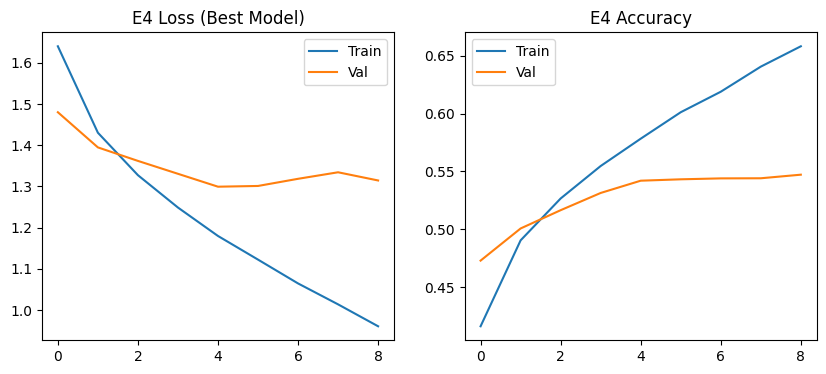

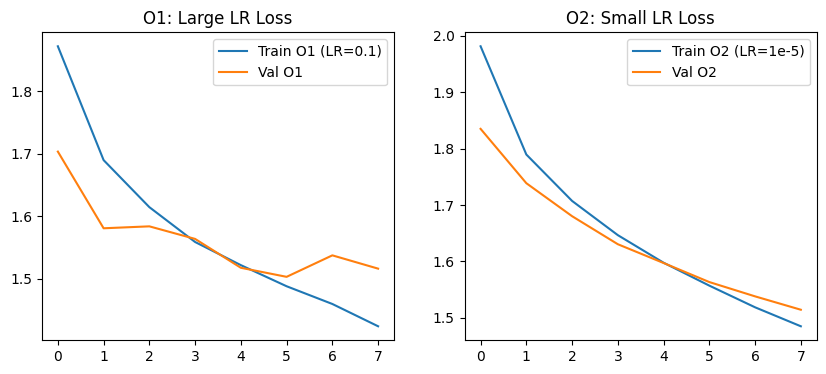

Final Test Accuracy for best model (E4): 0.5475


In [5]:
# График E4
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(histories['E4']['train_loss'], label='Train')
plt.plot(histories['E4']['val_loss'], label='Val')
plt.title('E4 Loss (Best Model)')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(histories['E4']['train_acc'], label='Train')
plt.plot(histories['E4']['val_acc'], label='Val')
plt.title('E4 Accuracy')
plt.legend()
plt.savefig('artifacts/figures/curves_best.png')
plt.show()

# Графики O1, O2
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(histories['O1']['train_loss'], label='Train O1 (LR=0.1)')
plt.plot(histories['O1']['val_loss'], label='Val O1')
plt.title('O1: Large LR Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(histories['O2']['train_loss'], label='Train O2 (LR=1e-5)')
plt.plot(histories['O2']['val_loss'], label='Val O2')
plt.title('O2: Small LR Loss')
plt.legend()
plt.savefig('artifacts/figures/curves_lr_extremes.png')
plt.show()

# Оценка E4 на test
model_E4.load_state_dict(best_models_states['E4'])
test_loss, test_acc = evaluate(model_E4, test_loader, nn.CrossEntropyLoss())
print(f"Final Test Accuracy for best model (E4): {test_acc:.4f}")